# PPO Training Example on ImprovedB747Env

This notebook demonstrates training a PPO agent from `tensoraerospace/agent/ppo/model.py` on the `ImprovedB747Env` environment from `tensoraerospace/envs/b747.py`.

Features:
- Continuous actions with a Gaussian policy
- Clipped surrogate objective for stable updates
- tqdm progress bar and TensorBoard logging (losses, policy stats, reward)
- Checkpointing with optional gradient saving for resuming training

In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.envs.b747_vec_torch import ImprovedB747VecEnvTorch
from tensoraerospace.agent.ppo.model import PPO

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(1)
_ = torch.manual_seed(1)


Using device: cuda


In [2]:
# Build environment
from typing import Optional

import gymnasium as gym

from tensoraerospace.signals.standart import sinusoid_vertical_shift, unit_step
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

def make_reference_signal(
    tp_sec: np.ndarray,
    kind: str,
    *,
    amplitude_deg: float = 1.0,
    frequency_hz: float = 0.05,
    step_time_sec: float = 5.0,
) -> np.ndarray:
    """Return reference signal shaped as (1, T) in radians."""
    tp_sec = np.asarray(tp_sec)

    if kind == "sine":
        sig = sinusoid_vertical_shift(
            tp=tp_sec,
            frequency=frequency_hz,
            amplitude=np.deg2rad(amplitude_deg),
            vertical_shift=0.0,
        )
    elif kind == "step":
        sig = unit_step(
            tp=tp_sec,
            degree=amplitude_deg,
            time_step=step_time_sec,
            output_rad=True,
        )
    else:
        raise ValueError(f"Unknown kind={kind!r}. Use 'sine' or 'step'.")

    return np.reshape(sig, [1, -1])


class RandomReferenceSignalWrapper(gym.Wrapper):
    """Randomize reference signal on every reset.

    For robust step tracking we randomize:
    - step amplitude (deg)
    - step time (sec)

    This prevents PPO from "anticipating" a fixed step time and drifting before the step.
    """

    def __init__(
        self,
        env: gym.Env,
        tp_sec: np.ndarray,
        *,
        fixed_kind: str = "step",
        p_step: float = 0.5,
        amplitude_deg_range: tuple[float, float] = (1.0, 10.0),
        step_time_sec_range: tuple[float, float] = (1.0, 10.0),
        frequency_hz: float = 0.05,
        seed: Optional[int] = None,
    ):
        super().__init__(env)
        self.tp_sec = np.asarray(tp_sec)
        self.fixed_kind = str(fixed_kind)
        self.p_step = float(p_step)
        self.amplitude_deg_range = (float(amplitude_deg_range[0]), float(amplitude_deg_range[1]))
        self.step_time_sec_range = (float(step_time_sec_range[0]), float(step_time_sec_range[1]))
        self.frequency_hz = float(frequency_hz)
        self.rng = np.random.default_rng(seed)

        # Diagnostics
        self.last_kind: Optional[str] = None
        self.last_amplitude_deg: Optional[float] = None
        self.last_step_time_sec: Optional[float] = None

    def _sample_and_set_reference(self) -> None:
        # Choose signal kind
        kind = self.fixed_kind
        if kind == "mixed":
            kind = "step" if float(self.rng.random()) < float(self.p_step) else "sine"

        # Sample amplitude + step time
        amp_lo, amp_hi = self.amplitude_deg_range
        amp_deg = float(self.rng.uniform(amp_lo, amp_hi))

        t0 = float(self.tp_sec[0])
        t1 = float(self.tp_sec[-1])
        st_lo, st_hi = self.step_time_sec_range
        step_time_sec = float(self.rng.uniform(st_lo, st_hi))
        step_time_sec = float(np.clip(step_time_sec, t0, t1))

        self.last_kind = kind
        self.last_amplitude_deg = amp_deg
        self.last_step_time_sec = step_time_sec

        self.env.reference_signal = make_reference_signal(
            self.tp_sec,
            kind,
            amplitude_deg=amp_deg,
            frequency_hz=self.frequency_hz,
            step_time_sec=step_time_sec,
        )

    def reset(self, seed=None, options=None):
        # If user passes seed, respect it for reference sampling too.
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self._sample_and_set_reference()
        return self.env.reset(seed=seed, options=options)


# Initial state [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Toggle: vectorized torch env (64 parallel envs)
USE_VEC_ENV = True
NUM_ENVS = 64

if USE_VEC_ENV:
    # Vectorized torch env (batched) — runs in torch (CUDA if DEVICE==cuda)
    env = ImprovedB747VecEnvTorch(
        num_envs=NUM_ENVS,
        dt=dt,
        tn=float(tps[-1]),
        initial_state=init_state,
        device=DEVICE,
        seed=1,
        auto_reset=True,
        # Curriculum-friendly ranges (faster convergence). You can widen later.
        step_randomization={
            "amplitude_deg_range": (1.0, 1.0),
            "min_abs_amplitude_deg": 1.0,  # avoid near-zero trivial steps
            "step_time_sec_range": (5.0, 5.0),  # leave enough time to settle
        },
    )

    obs, info = env.reset()

    # Hard guard: if you see anything other than (NUM_ENVS, 4), you're NOT using vec env
    try:
        import torch

        assert hasattr(env, "num_envs") and int(env.num_envs) == int(NUM_ENVS)
        assert torch.is_tensor(obs) and tuple(obs.shape) == (int(NUM_ENVS), 4)
    except Exception as e:
        raise RuntimeError(
            "USE_VEC_ENV=True but env/obs are not vectorized. "
            "Re-run Cell 2 top-to-bottom. Expected obs shape (NUM_ENVS, 4)."
        ) from e

    print("Vec obs shape:", tuple(obs.shape))
    print("num_envs:", env.num_envs)
    print("device:", env.device)
    print("Action space:", env.action_space)
    print("Observation space:", env.observation_space)
else:
    # Base env (reference gets overwritten by wrapper on reset anyway)
    base_env = ImprovedB747Env(
        initial_state=init_state,
        reference_signal=make_reference_signal(tps, "sine"),
        number_time_steps=number_time_steps,
        dt=dt,
        initial_elevator_deg=0.0,
    )

    # Train on randomized step times + amplitudes (robustness)
    env = RandomReferenceSignalWrapper(
        base_env,
        tps,
        fixed_kind="step",  # use "mixed" if you also want sine
        amplitude_deg_range=(1.0, 10.0),
        step_time_sec_range=(1.0, 10.0),
        frequency_hz=0.05,
        seed=1,
    )

    obs, info = env.reset()
    print("Obs shape:", np.array(obs).shape)
    print("Action space:", env.action_space)
    print("Observation space:", env.observation_space)
    print("Sampled reference kind:", env.last_kind)
    print("Sampled step amplitude (deg):", env.last_amplitude_deg)
    print("Sampled step time (sec):", env.last_step_time_sec)


Obs shape: (4,)
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(-1.0, 1.0, (4,), float32)


In [19]:
# Load checkpoint (best if available) and continue/evaluate
from pathlib import Path


def pick_checkpoint_dir(
    preferred: str = best_model_dir if "best_model_dir" in globals() else (
        "./b747_vec64_step_best_091_06st" if ("USE_VEC_ENV" in globals() and USE_VEC_ENV) else "./b747_vec64_step_best_091_06st"
    ),
    fallback_root: str = save_root_dir if "save_root_dir" in globals() else (
        "./ppo_b747_vec64" if ("USE_VEC_ENV" in globals() and USE_VEC_ENV) else "./ppo_b747_improved"
    ),
) -> Path:
    preferred_p = Path(preferred)
    if preferred_p.exists() and (preferred_p / "config.json").exists():
        return preferred_p

    root = Path(fallback_root)
    if root.exists() and root.is_dir():
        # pick newest subdir that looks like a saved PPO folder
        subdirs = sorted(
            [p for p in root.iterdir() if p.is_dir()],
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        for p in subdirs:
            if (p / "config.json").exists():
                return p

    raise FileNotFoundError(
        f"No checkpoint found. Tried {preferred_p.resolve()} and {root.resolve()}/*/config.json"
    )


ckpt_dir = pick_checkpoint_dir()
print("Loading checkpoint from:", ckpt_dir.resolve())
agent_eval = PPO.from_pretrained("TensorAeroSpace/ppo-b747-step-response")
print("Loaded agent_eval. best_reward:", getattr(agent_eval, "best_reward", None))



Loading checkpoint from: /home/mr8bit/Projects/TensorAeroSpace/example/comparison/b747_vec64_step_best_091_06st


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

actor.pth:   0%|          | 0.00/274k [00:00<?, ?B/s]

Loaded agent_eval. best_reward: 0.9137129187583923


Single scenario: amplitude=5.0 deg, step_time=5.0 s


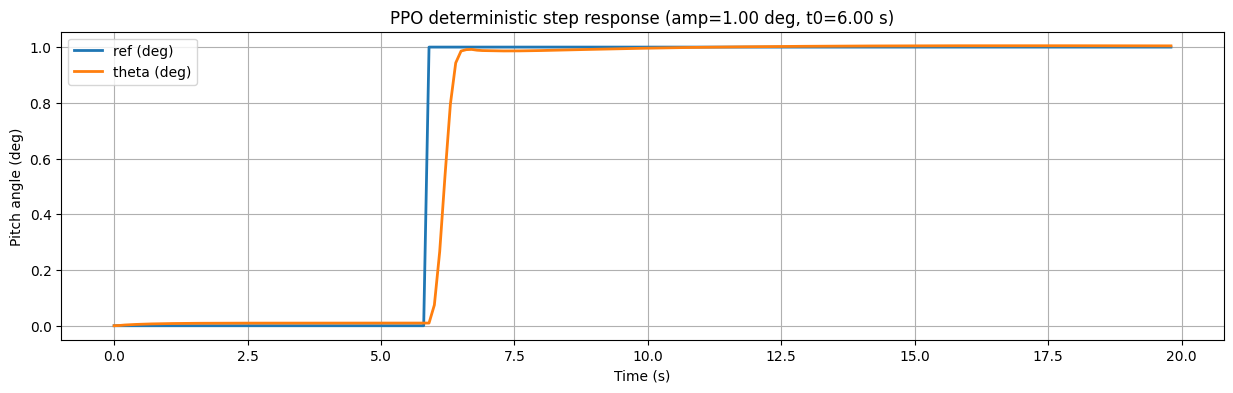

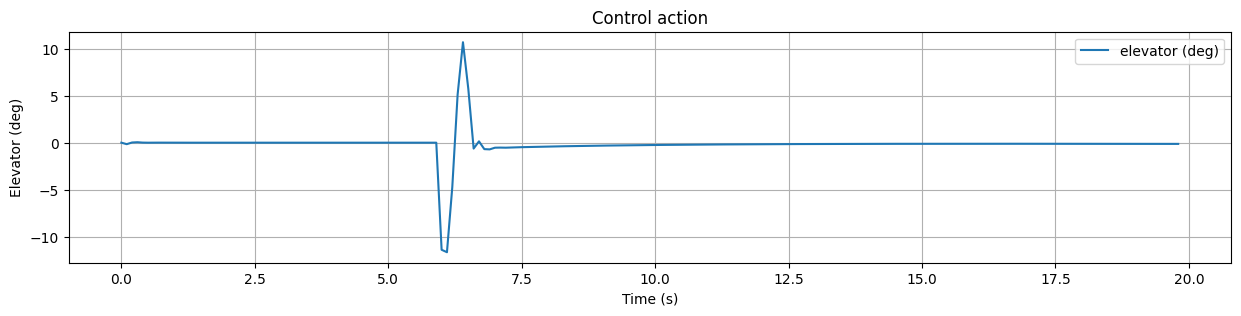


Benchmark metrics:
{'overshoot': 0.490081030048084, 'settling_time': 0.6000000000000001, 'damping_degree': -0.013385896751501924, 'static_error': -0.004588705602692311, 'rise_time': 0.30000000000000004, 'peak_time': 0.8, 'maximum_deviation': 0.9904672219158875, 'iae': 4.084775990875998, 'ise': 2.638744507103076, 'itae': 4.774945410025388, 'oscillation_count': 1, 'steady_state_value': 1.0, 'performance_index': 3.0634921728610025}


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: PPO checkpoint                                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:         0.49%              


Robustness check: 8 random scenarios

--- Case 1/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

--- Case 2/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

--- Case 3/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

--- Case 4/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

--- Case 5/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

--- Case 6/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

--- Case 7/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

--- Case 8/8: amp=1.00 deg, step_time=5.00 s ---
  overshoot=0.49%, settling_time=0.60s, static_error=-0.0043

Summary Table


,amp_deg,step_time_s,overshoot,settling_time,static_error,oscillation_count,performance_index
0,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762
1,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762
2,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762
3,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762
4,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762
5,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762
6,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762
7,1.0,5.0,0.490481,0.6,-0.004314,1,3.309762



Statistics:


,overshoot,settling_time,static_error,oscillation_count,performance_index
count,8.000000,8.0,8.000000,8.0,8.000000
mean,0.490481,0.6,-0.004314,1.0,3.309762
std,0.000000,0.0,0.000000,0.0,0.000000
min,0.490481,0.6,-0.004314,1.0,3.309762
25%,0.490481,0.6,-0.004314,1.0,3.309762
50%,0.490481,0.6,-0.004314,1.0,3.309762
75%,0.490481,0.6,-0.004314,1.0,3.309762
max,0.490481,0.6,-0.004314,1.0,3.309762


In [20]:
# Deterministic rollout + transient plot + benchmark
# Self-contained cell: includes all necessary imports and helpers

import numpy as np
import matplotlib.pyplot as plt

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.benchmark import ControlBenchmark
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# --- Re-define evaluation parameters (in case cells were run out of order) ---
_dt = 0.1
_tp = generate_time_period(tn=20, dt=_dt)
_tps = convert_tp_to_sec_tp(_tp, dt=_dt)
_number_time_steps = len(_tp)
_init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)


def _make_reference_signal(
    tp_sec: np.ndarray,
    kind: str,
    *,
    amplitude_deg: float = 1.0,
    step_time_sec: float = 5.0,
) -> np.ndarray:
    """Return reference signal shaped as (1, T) in radians."""
    tp_sec = np.asarray(tp_sec)
    if kind == "step":
        sig = unit_step(
            tp=tp_sec,
            degree=amplitude_deg,
            time_step=step_time_sec,
            output_rad=True,
        )
    else:
        raise ValueError(f"Unknown kind={kind!r}. Use 'step'.")
    return np.reshape(sig, [1, -1])


def run_step_episode(
    agent,
    *,
    amplitude_deg: float,
    step_time_sec: float,
    show_plots: bool = True,
    show_report: bool = True,
) -> dict:
    """Run deterministic evaluation episode and compute benchmark metrics.
    
    Args:
        agent: Trained PPO agent.
        amplitude_deg: Step amplitude in degrees.
        step_time_sec: Time when step occurs (seconds).
        show_plots: Whether to display matplotlib plots.
        show_report: Whether to print benchmark report.
    
    Returns:
        Dictionary with time, signals, and metrics.
    """
    ref = _make_reference_signal(
        _tps,
        "step",
        amplitude_deg=float(amplitude_deg),
        step_time_sec=float(step_time_sec),
    )

    eval_env = ImprovedB747Env(
        initial_state=_init_state,
        reference_signal=ref,
        number_time_steps=_number_time_steps,
        dt=_dt,
        initial_elevator_deg=0.0,
    )

    obs, _ = eval_env.reset()

    theta_rad_hist: list[float] = []
    ref_rad_hist: list[float] = []
    elev_deg_hist: list[float] = []

    terminated = False
    truncated = False
    while not (terminated or truncated):
        # agent.act returns (action_tensor, mean_action_np, log_prob_tensor)
        action_t, mean_action_np, _ = agent.act(obs, deterministic=True)
        # mean_action_np is numpy array of shape (action_dim,); extract scalar for step()
        action_scalar = float(np.asarray(mean_action_np).flatten()[0])
        obs, reward, terminated, truncated, info = eval_env.step(action_scalar)

        # Record state
        theta_rad_hist.append(float(eval_env.state[eval_env._idx_theta]))
        idx = int(np.clip(eval_env.current_step, 0, eval_env.reference_signal.shape[1] - 1))
        ref_rad_hist.append(float(eval_env.reference_signal[0, idx]))
        elev_deg_hist.append(float(eval_env.previous_action * eval_env.max_stabilizer_angle_deg))

    theta_rad = np.asarray(theta_rad_hist)
    ref_rad = np.asarray(ref_rad_hist)
    elev_deg = np.asarray(elev_deg_hist)

    t_eval = _tps[: len(theta_rad)]

    # Convert to degrees for plots and benchmark
    ref_deg = np.rad2deg(ref_rad)
    theta_deg = np.rad2deg(theta_rad)

    # Plots
    if show_plots:
        plt.figure(figsize=(15, 4))
        plt.plot(t_eval, ref_deg, label="ref (deg)", linewidth=2)
        plt.plot(t_eval, theta_deg, label="theta (deg)", linewidth=2)
        plt.grid(True)
        plt.legend()
        plt.title(f"PPO deterministic step response (amp={amplitude_deg:.2f} deg, t0={step_time_sec:.2f} s)")
        plt.xlabel("Time (s)")
        plt.ylabel("Pitch angle (deg)")
        plt.show()

        plt.figure(figsize=(15, 3))
        plt.plot(t_eval, elev_deg, label="elevator (deg)")
        plt.grid(True)
        plt.legend()
        plt.title("Control action")
        plt.xlabel("Time (s)")
        plt.ylabel("Elevator (deg)")
        plt.show()

    # Benchmark
    bench = ControlBenchmark()
    metrics = bench.becnchmarking_one_step(
        control_signal=ref_deg,
        system_signal=theta_deg,
        signal_val=0.0,
        dt=_dt,
    )

    if show_report:
        print("\nBenchmark metrics:")
        print(metrics)

        print(
            "\n"
            + bench.generate_report(
                control_signal=ref_deg,
                system_signal=theta_deg,
                signal_val=0.0,
                dt=_dt,
                system_name="PPO checkpoint",
            )
        )

        bench.plot(
            control_signal=ref_deg,
            system_signal=theta_deg,
            signal_val=0.0,
            dt=_dt,
            tps=t_eval,
            title="PPO — benchmark",
        )

    return {
        "t": t_eval,
        "ref_deg": ref_deg,
        "theta_deg": theta_deg,
        "elev_deg": elev_deg,
        "metrics": metrics,
    }


# --- Single chosen scenario (edit these to validate specific cases)
print("=" * 60)
print("Single scenario: amplitude=5.0 deg, step_time=5.0 s")
print("=" * 60)
agent_to_eval = agent_eval if "agent_eval" in globals() else agent
res = run_step_episode(agent_to_eval, amplitude_deg=1.0, step_time_sec=6.0)

# --- Optional: quick robustness check on multiple random (amp, step_time)
RUN_ROBUSTNESS_CHECK = True
N_CASES = 8

if RUN_ROBUSTNESS_CHECK:
    print("\n" + "=" * 60)
    print(f"Robustness check: {N_CASES} random scenarios")
    print("=" * 60)
    
    rng = np.random.default_rng(123)
    
    # Default ranges for robustness check (matches training config)
    amp_lo, amp_hi = (1.0, 1.0)
    st_lo, st_hi = (5.0, 5.0)

    rows = []
    for i in range(N_CASES):
        amp = float(rng.uniform(amp_lo, amp_hi))
        st = float(rng.uniform(st_lo, st_hi))
        print(f"\n--- Case {i+1}/{N_CASES}: amp={amp:.2f} deg, step_time={st:.2f} s ---")
        out = run_step_episode(agent_to_eval, amplitude_deg=amp, step_time_sec=st, show_plots=False, show_report=False)
        m = out["metrics"].copy()
        m.update({"amp_deg": amp, "step_time_s": st})
        rows.append(m)
        print(f"  overshoot={m['overshoot']:.2f}%, settling_time={m['settling_time']:.2f}s, static_error={m['static_error']:.4f}")

    # Summary table
    try:
        import pandas as pd

        df = pd.DataFrame(rows)
        print("\n" + "=" * 60)
        print("Summary Table")
        print("=" * 60)
        display(df[["amp_deg", "step_time_s", "overshoot", "settling_time", "static_error", "oscillation_count", "performance_index"]])
        print("\nStatistics:")
        display(df[["overshoot", "settling_time", "static_error", "oscillation_count", "performance_index"]].describe())
    except Exception as e:
        print(f"\nCould not create pandas table: {e}")
        print("\nRobustness metrics (first 3):")
        for r in rows[:3]:
            print(r)

